In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 4.3 MB/s eta 0:00:00


In [ ]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
query = "select * from churndb"

In [ ]:
con = snowflake.connector.connect(
    user = "Alaguraja",
    password = "Alagurajakannan@787",
    account = "DXMKEOQ-ON75318",
    database = "churn",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [ ]:
df = pd.read_sql(query, con)

/tmp/ipykernel_1467/1914986641.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


In [ ]:
df

,ROWNUMBER,CUSTOMERID,SURNAME,CREDITSCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ROWNUMBER        10000 non-null  int64  
 1   CUSTOMERID       10000 non-null  int64  
 2   SURNAME          10000 non-null  object 
 3   CREDITSCORE      10000 non-null  int64  
 4   GEOGRAPHY        10000 non-null  object 
 5   GENDER           10000 non-null  object 
 6   AGE              10000 non-null  int64  
 7   TENURE           10000 non-null  int64  
 8   BALANCE          10000 non-null  float64
 9   NUMOFPRODUCTS    10000 non-null  int64  
 10  HASCRCARD        10000 non-null  int64  
 11  ISACTIVEMEMBER   10000 non-null  int64  
 12  ESTIMATEDSALARY  10000 non-null  float64
 13  EXITED           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,ROWNUMBER,CUSTOMERID,CREDITSCORE,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,ROWNUMBER,CUSTOMERID,SURNAME,CREDITSCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


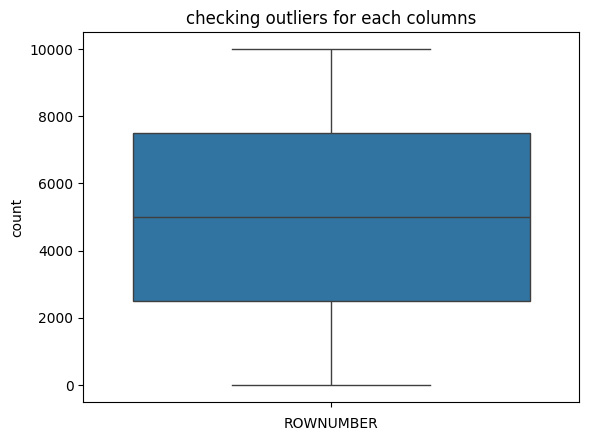

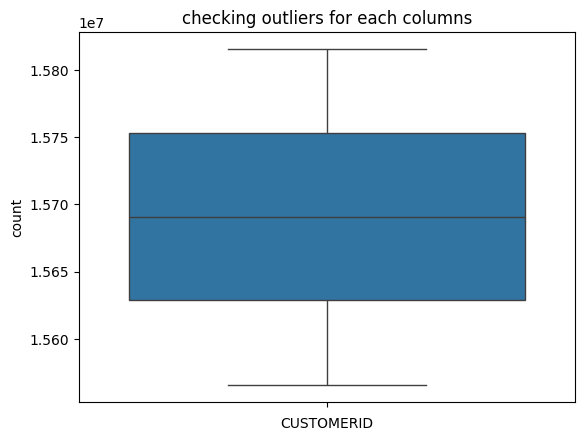

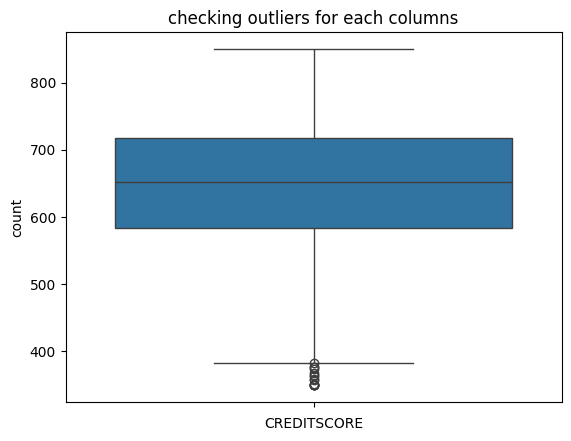

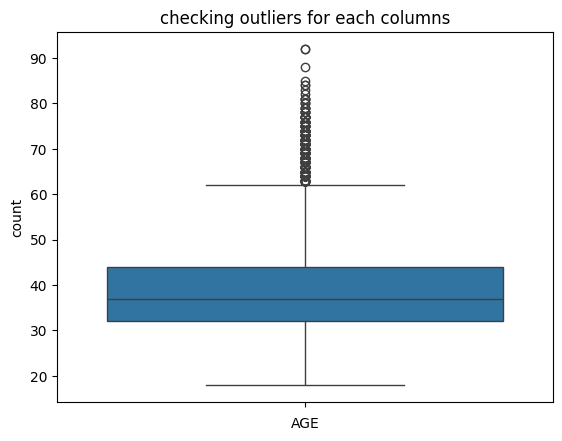

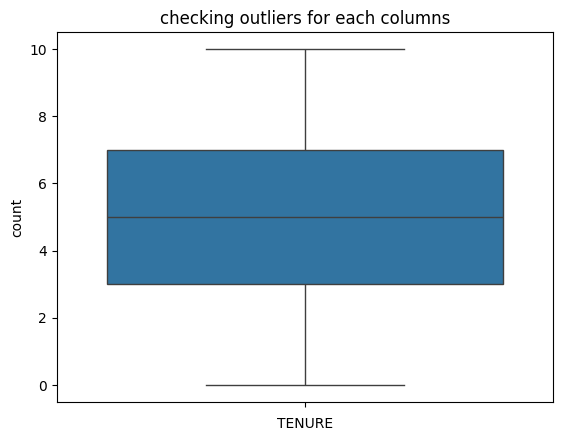

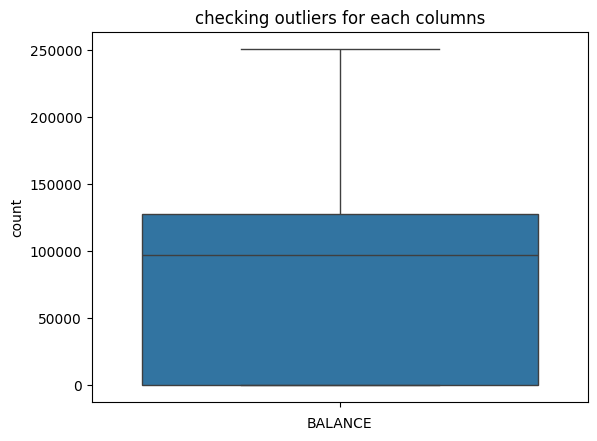

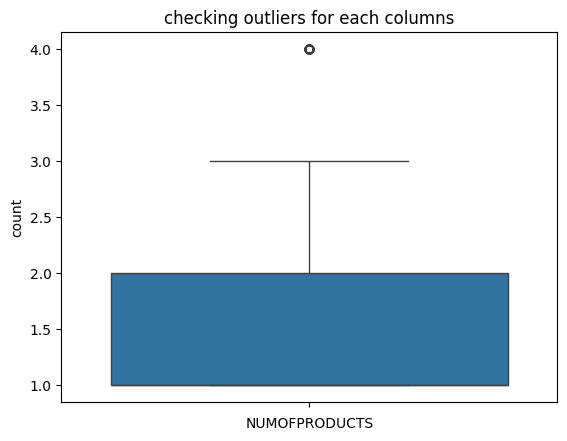

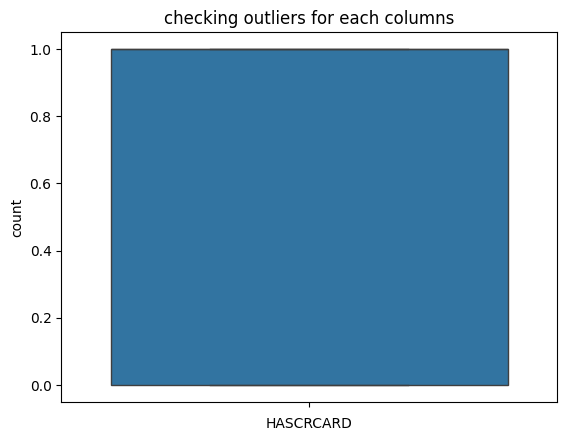

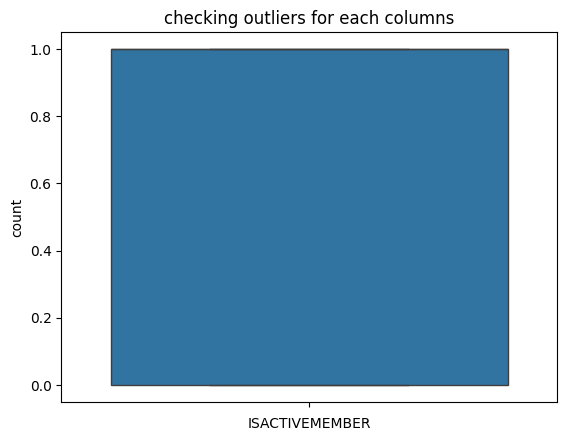

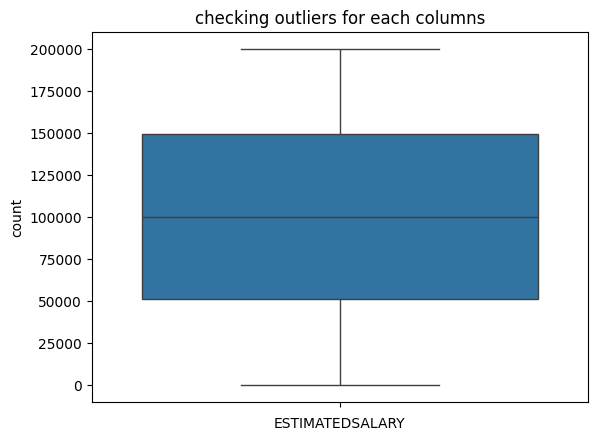

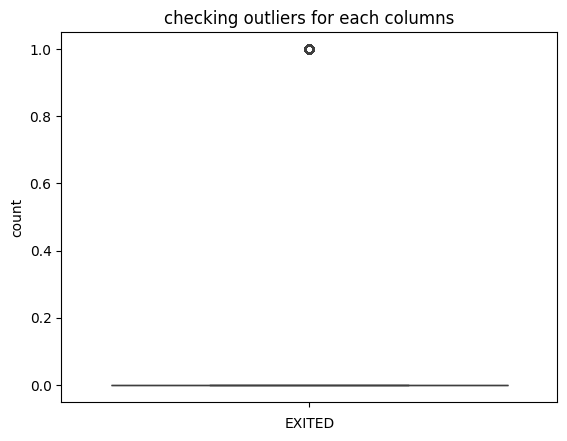

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    sns.boxplot(df[i])
    plt.title("checking outliers for each columns")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
col = ["AGE", "CREDITSCORE", "NUMOFPRODUCTS"]

In [ ]:
for i in col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr
  df = df[(lower_fence <= df[i]) & (upper_fence >= df[i])]

In [ ]:
df["EXITED"].unique()

array([1, 0])

In [ ]:
df["EXITED"].value_counts()

,count
EXITED,
0,7584
1,1820


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i] = le.fit_transform(df[i])

In [ ]:
df.head()

,ROWNUMBER,CUSTOMERID,SURNAME,CREDITSCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
0,1,15634602,1079,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,1138,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,1974,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,281,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,1763,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
x = df.iloc[:,:-1]
y = df["EXITED"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import *
print("Performance of my model: ", accuracy_score(y_test, y_pred)*100)

Performance of my model:  80.75491759702285
